In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from statsmodels.stats.contingency_tables import mcnemar

# ----------------------------------------------------------------
# 1. Load & clean data
# ----------------------------------------------------------------
df = pd.read_csv('Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# ----------------------------------------------------------------
# 2. Separate feature types
#    Nominal (no inherent order) -> OneHotEncoder
#    Ordinal/binary              -> OrdinalEncoder (or as-is after map)
#    Numeric                     -> StandardScaler (inside pipeline per model)
# ----------------------------------------------------------------
nominal_cols = [
    'InternetService', 'Contract', 'PaymentMethod'
]
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling'
]
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Label-encode binary columns (they are genuinely 2-class)
from sklearn.preprocessing import LabelEncoder
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)






# ----------------------------------------------------------------
# 3. Preprocessor (shared except Scaler applied per model pipeline)
# ----------------------------------------------------------------
ohe = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), nominal_cols)
    ],
    remainder='passthrough'
)

# Preprocessor WITH scaling (for LR)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessor_scaled = Pipeline([
    ('ohe', ohe),
    ('scaler', StandardScaler())
])

# ----------------------------------------------------------------
# 4. Build pipelines
# ----------------------------------------------------------------
lr_pipe = Pipeline([
    ('pre', preprocessor_scaled),
    ('clf', LogisticRegression(
        solver='saga',          # handles L2, converges reliably
        max_iter=5000,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipe = Pipeline([
    ('pre', ohe),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

xgb_pipe = Pipeline([
    ('pre', ohe),
    ('clf', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # handles imbalance
        eval_metric='logloss',
        random_state=42
    ))
])

pipelines = {
    'Logistic Regression': lr_pipe,
    'Random Forest':       rf_pipe,
    'XGBoost':             xgb_pipe,
}

# ----------------------------------------------------------------
# 5. 5-Fold Stratified Cross-Validation
# ----------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'CV Accuracy':  f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'CV Recall':    f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV F1':        f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':   f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
    }

cv_df = pd.DataFrame(cv_results).T
print('\n=== 5-Fold Cross-Validation Results ===')
print(cv_df.to_string())
cv_df.to_csv('cv_results.csv')



=== 5-Fold Cross-Validation Results ===
                         CV Accuracy     CV Precision        CV Recall            CV F1       CV ROC-AUC
Logistic Regression  0.7513 ± 0.0048  0.5209 ± 0.0060  0.8020 ± 0.0160  0.6315 ± 0.0073  0.8459 ± 0.0054
Random Forest        0.7778 ± 0.0081  0.5726 ± 0.0142  0.6475 ± 0.0275  0.6075 ± 0.0161  0.8297 ± 0.0068
XGBoost              0.7616 ± 0.0086  0.5363 ± 0.0113  0.7619 ± 0.0235  0.6294 ± 0.0138  0.8448 ± 0.0046


In [3]:
# ----------------------------------------------------------------
# 6. Hold-out test set evaluation
# ----------------------------------------------------------------
test_results = []
predictions  = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    predictions[name] = pred

    test_results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1-Score':  round(f1_score(y_test, pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(test_results)
print('\n=== Hold-out Test Results ===')
print(results_df.to_string(index=False))
results_df.to_csv('model_comparison_table_improved.csv', index=False)

# Confusion matrices
for name, pipe in pipelines.items():
    pred = predictions[name]
    print(f'\nConfusion Matrix — {name}')
    print(confusion_matrix(y_test, pred))



=== Hold-out Test Results ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7264     0.4909  0.7968    0.6075   0.8350
      Random Forest    0.7655     0.5495  0.6524    0.5966   0.8188
            XGBoost    0.7441     0.5122  0.7888    0.6211   0.8333

Confusion Matrix — Logistic Regression
[[724 309]
 [ 76 298]]

Confusion Matrix — Random Forest
[[833 200]
 [130 244]]

Confusion Matrix — XGBoost
[[752 281]
 [ 79 295]]


In [4]:
# ----------------------------------------------------------------
# 7. McNemar's Test (pairwise statistical comparison)
#    Tests whether two classifiers make significantly different errors
# ----------------------------------------------------------------
def mcnemar_test(y_true, pred_a, pred_b, label_a, label_b):
    """Compute McNemar contingency table and p-value."""
    # b: A correct, B wrong | c: A wrong, B correct
    b = np.sum((pred_a == y_true) & (pred_b != y_true))
    c = np.sum((pred_a != y_true) & (pred_b == y_true))
    table = [[0, b], [c, 0]]   # only off-diagonals matter
    result = mcnemar(table, exact=False, correction=True)
    print(f'{label_a} vs {label_b}: b={b}, c={c}, chi2={result.statistic:.4f}, p={result.pvalue:.4f}')
    return result.pvalue

print('\n=== McNemar Statistical Tests (alpha = 0.05) ===')
p_lr_rf  = mcnemar_test(y_test, predictions['Logistic Regression'],
                         predictions['Random Forest'], 'LR', 'RF')
p_lr_xgb = mcnemar_test(y_test, predictions['Logistic Regression'],
                         predictions['XGBoost'], 'LR', 'XGBoost')
p_rf_xgb = mcnemar_test(y_test, predictions['Random Forest'],
                         predictions['XGBoost'], 'RF', 'XGBoost')

for pair, p in [('LR vs RF', p_lr_rf), ('LR vs XGB', p_lr_xgb), ('RF vs XGB', p_rf_xgb)]:
    sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'  {pair}: {sig} (p={p:.4f})')



=== McNemar Statistical Tests (alpha = 0.05) ===
LR vs RF: b=89, c=144, chi2=12.5150, p=0.0004
LR vs XGBoost: b=53, c=78, chi2=4.3969, p=0.0360
RF vs XGBoost: b=98, c=68, chi2=5.0663, p=0.0244
  LR vs RF: SIGNIFICANT (p=0.0004)
  LR vs XGB: SIGNIFICANT (p=0.0360)
  RF vs XGB: SIGNIFICANT (p=0.0244)



=== Top 15 Features by LR Coefficient Magnitude ===
                       Feature  Coefficient  Abs_Coef
                        tenure    -1.249970  1.249970
                MonthlyCharges    -0.765864  0.765864
   InternetService_Fiber optic     0.681325  0.681325
            InternetService_No    -0.673338  0.673338
             Contract_Two year    -0.636892  0.636892
                  TotalCharges     0.608131  0.608131
             Contract_One year    -0.326678  0.326678
                   StreamingTV     0.212641  0.212641
               StreamingMovies     0.206369  0.206369
PaymentMethod_Electronic check     0.194725  0.194725
                 MultipleLines     0.182487  0.182487
                OnlineSecurity    -0.129689  0.129689
              PaperlessBilling     0.124580  0.124580
                   TechSupport    -0.111189  0.111189
                    Dependents    -0.103855  0.103855


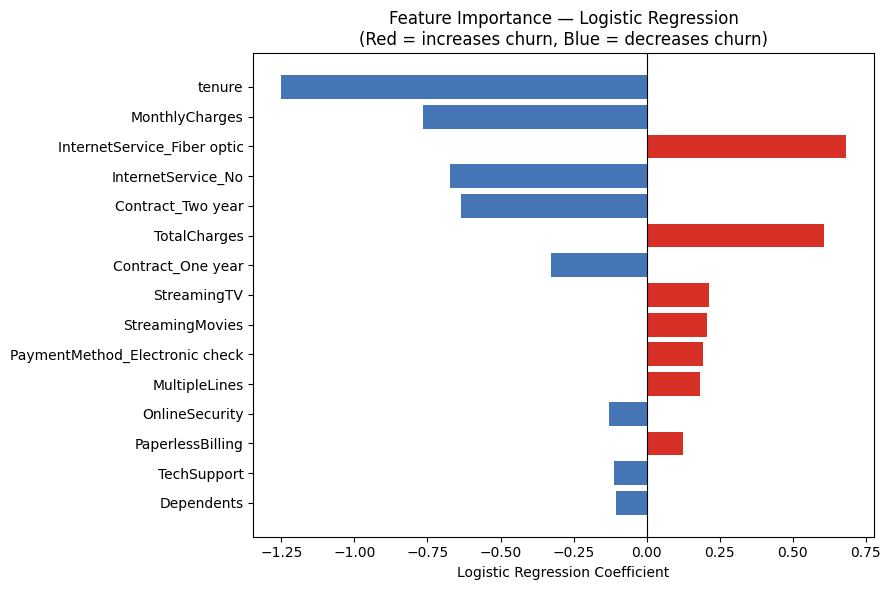

In [5]:
# ----------------------------------------------------------------
# 8. Feature Importance from Logistic Regression (correct approach)
#    Use |coefficient| after fitting the scaled pipeline
# ----------------------------------------------------------------
lr_fitted = pipelines['Logistic Regression']

# Get feature names after OHE
ohe_step = lr_fitted.named_steps['pre'].named_steps['ohe']
ohe_feature_names = ohe_step.named_transformers_['ohe'].get_feature_names_out(nominal_cols).tolist()
remaining_features = [c for c in X.columns if c not in nominal_cols]
all_features = ohe_feature_names + remaining_features

coefs = lr_fitted.named_steps['clf'].coef_[0]
importance_df = pd.DataFrame({
    'Feature':    all_features,
    'Coefficient': coefs,
    'Abs_Coef':   np.abs(coefs)
}).sort_values('Abs_Coef', ascending=False).head(15)

print('\n=== Top 15 Features by LR Coefficient Magnitude ===')
print(importance_df[['Feature','Coefficient','Abs_Coef']].to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d73027' if c > 0 else '#4575b4' for c in importance_df['Coefficient']]
ax.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title('Feature Importance — Logistic Regression\n(Red = increases churn, Blue = decreases churn)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_LR.png', dpi=150)
plt.show()
importance_df.to_csv('feature_importance_LR.csv', index=False)


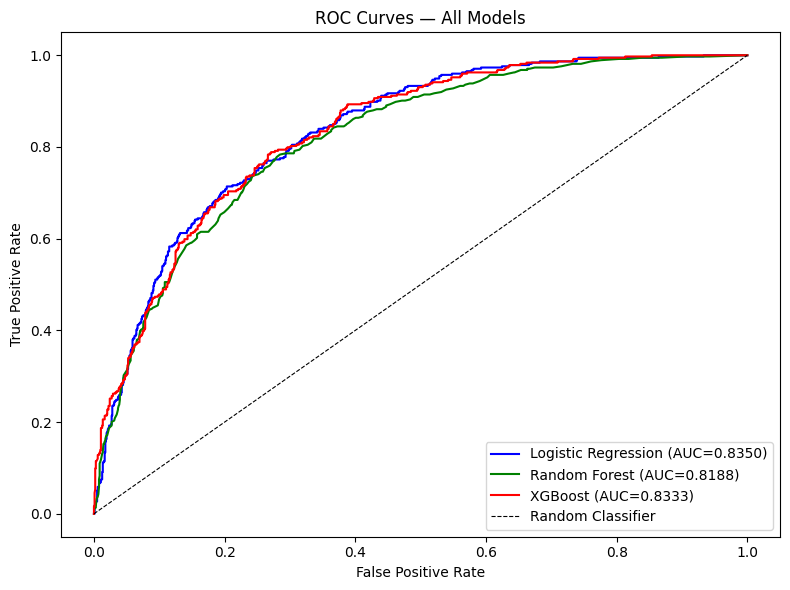

In [6]:
# ----------------------------------------------------------------
# 9. ROC Curves — all three models on one plot
# ----------------------------------------------------------------
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = {'Logistic Regression': 'blue', 'Random Forest': 'green', 'XGBoost': 'red'}

for name, pipe in pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=colors_roc[name])

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves_combined.png', dpi=150)
plt.show()


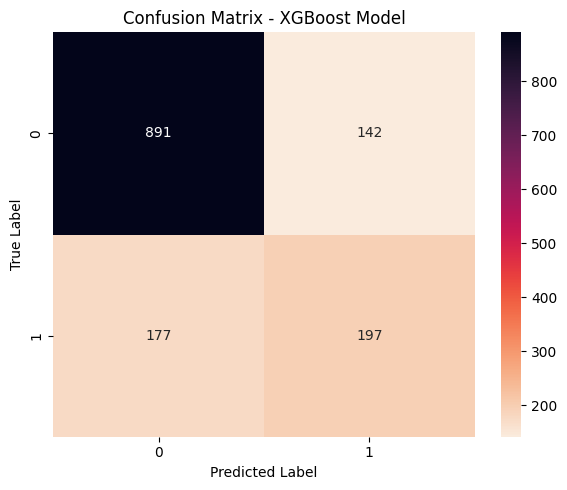

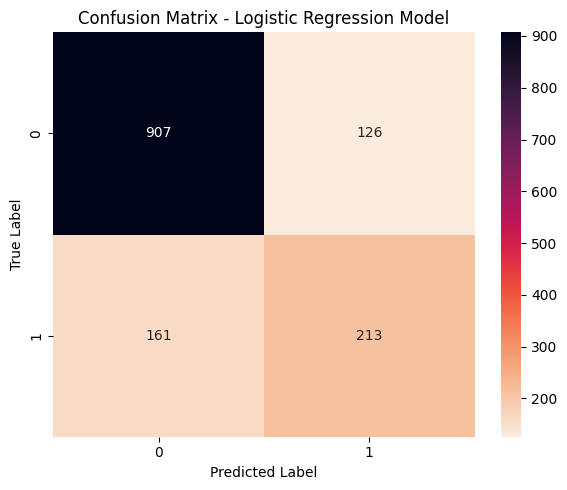

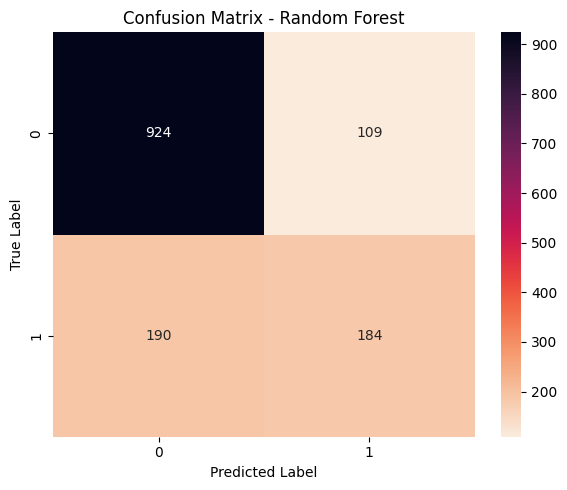

In [7]:
# 3) Figure 3 - Confusion Matrix 

# ----------------------------
# 1) Load & clean data (same preprocessing as the rest of the paper)
# ----------------------------
# df = pd.read_csv("Telco-Customer-Churn.csv")
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df.dropna(inplace=True)
# df.drop(columns=['customerID'], inplace=True)   # must be dropped, it's just an ID

# temp = df.copy()
# cat_cols = temp.select_dtypes(include=['object', 'string']).columns
# for col in cat_cols:
#     temp[col] = LabelEncoder().fit_transform(temp[col])

# X = temp.drop('Churn', axis=1)
# y = temp['Churn']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )





# 1. Load & clean data
df = pd.read_csv('Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)

# Encode ALL categorical columns with LabelEncoder (same as cell 1)
temp = df.copy()
cat_cols = temp.select_dtypes(include=['object', 'string']).columns
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    temp[col] = LabelEncoder().fit_transform(temp[col])

X = temp.drop('Churn', axis=1)
y = temp['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# --------------------------------------



xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
proba_xgb = xgb.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', cbar=True)
plt.title("Confusion Matrix - XGBoost Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figure3_confusion_matrix_xgboost.png", dpi=300)
plt.show()

# ------------------------------


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
proba_lr = lr.predict_proba(X_test)[:, 1]

cm_lr = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='rocket_r', cbar=True)
plt.title("Confusion Matrix - Logistic Regression Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figure3_confusion_matrix_LogisticRegression.png", dpi=300)
plt.show()




# ------------------------------

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='rocket_r', cbar=True)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figure3_confusion_matrix_RandomForest.png", dpi=300)
plt.show()


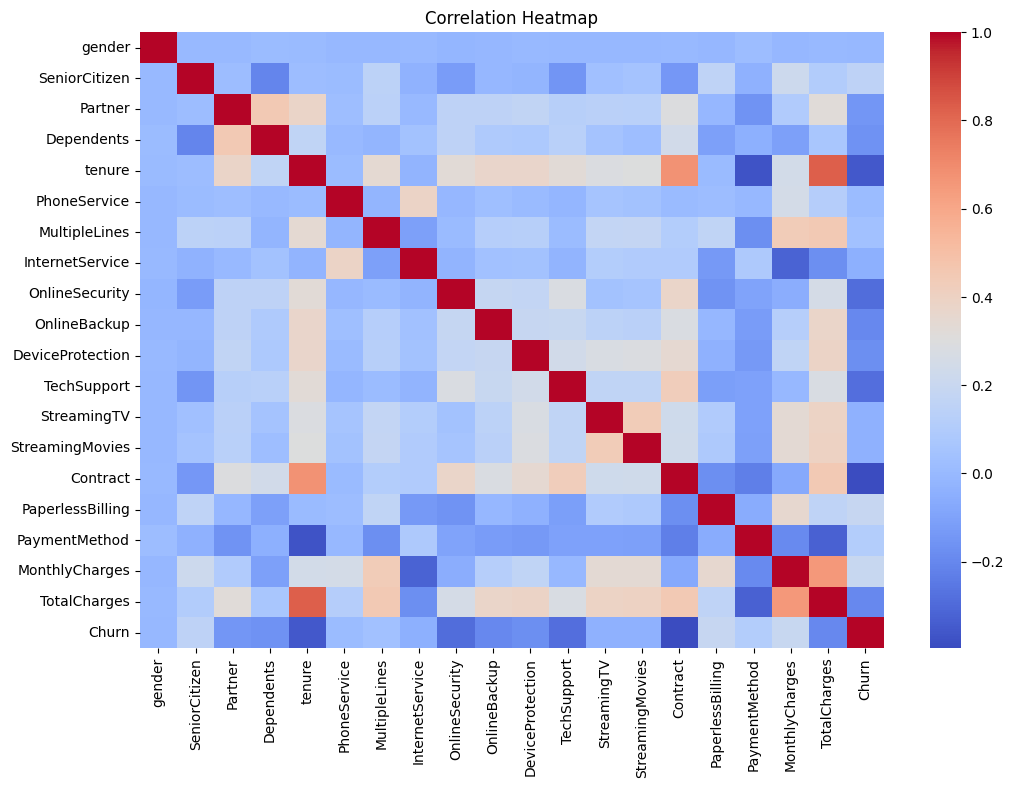

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

for col in temp.columns:
    if temp[col].dtype == 'object':
        temp[col] = LabelEncoder().fit_transform(temp[col])

plt.figure(figsize=(12,8))

sns.heatmap(
    temp.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.savefig("figure3_heatmap.png", dpi=300)
plt.show()

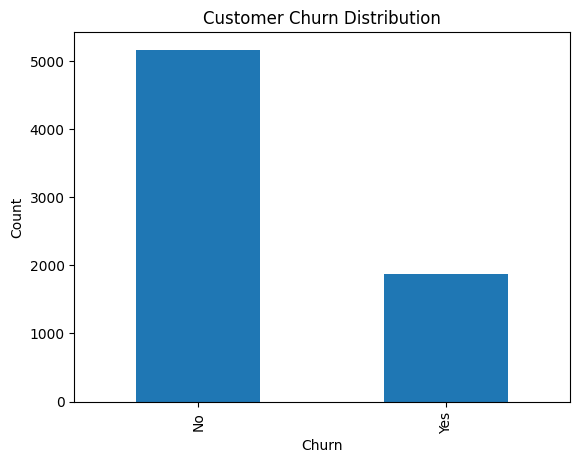

In [9]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig("Customer Churn Distribution.png" , dpi=200)

plt.show()